# SQL 02 — Joins, CTEs and window functions

**Time:** about 2.5 hours. Roughly 30 minutes of reading and demonstration, the rest is you writing SQL.

## 📚 Learning objectives

By the end of this notebook you can:

- Write an `INNER JOIN` and a `LEFT JOIN`, and **say in advance** how many rows each will return.
- Recognise **fan-out** — the moment a join returns *more* rows than the table you started with — and fix it.
- Replace a nested subquery with a `WITH` clause (a **CTE**) that another person can read.
- Use `ROW_NUMBER`, `RANK`, `DENSE_RANK`, `LAG` and `SUM() OVER` to answer questions that are painful without them.
- Explain what your query would do to a number somebody is about to put in a report.

## Why this notebook exists

The market scan behind this `SQL/` folder read 322 real job postings, 183 of them located in
Saudi Arabia. **SQL was named in 63 of those 183 postings (34%)** — four times more often than
"deep learning" or "neural network" (15 of 183, 8%). A Riyadh fintech posting for a Data Analyst
does not ask for "SQL" in the abstract. It asks for this:

> "Strong SQL. You can write and debug complex **joins, window functions, and CTEs** against a
> large transactional schema without hand-holding." … "Ability to scope a vague business question
> into something answerable, and to say clearly when the data can't answer it."

Joins, CTEs, window functions. That sentence is the syllabus for this notebook, in that order.

## 🔗 Where this fits

**Builds on:** lesson 01 in this folder — `SELECT`, `WHERE`, `GROUP BY`, `ORDER BY` on the same
`calls` table, built from the same file. (The second table, `zip_areas`, is new here.) If you cannot yet write a `GROUP BY` that counts calls per township, do lesson 01 first.
It also builds on Course 05 (AIAT 115) Unit 1, lesson 01, which profiled this same 911 call log in
pandas and found that **3,025 of the 25,000 rows (12.1%) have no ZIP code**. That hole is not a
detail here. It is the whole first half of this lesson.

**Used later in:** lesson 03 in this folder, `03_the_row_count_is_wrong.ipynb`, which debugs queries
that run cleanly and return a wrong number — join fan-out is the first of the six failures it takes
apart. The same operation exists in pandas as `df.merge(..., how="left")`, shown on a two-row example
in Course 02 (AIAT 112) Unit 1 lesson 01; fan-out bites there in exactly the same way, and nothing in
that lesson warns you. And it is used in any project where the data starts in a database rather than
in a CSV — which, in a job, is most of them.

**Not part of the 12 official courses.** The official TVTC plan for this diploma contains no SQL.
See `SQL/README.md` for why this folder exists anyway.

---

## Part 0 — Set up

Two cells. The first finds the repository and the shared data loader; it works from this folder,
from the repository root, and on Google Colab. The second builds the database.

Everything below uses Python's built-in `sqlite3`. There is nothing to install, no server to start
and no password. The whole database lives in memory inside this kernel.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...

import sqlite3, hashlib
import pandas as pd

# This is the SQLite ENGINE compiled into Python, not your Python version. Part 4 needs 3.25
# or newer; the last section of this notebook checks that properly and says what to do.
print("SQLite engine version :", sqlite3.sqlite_version)

SQLite engine version : 3.52.0


## The database: two tables, both derived from one real file

The source is the **Montgomery County, Pennsylvania 911 emergency call log** — a real dispatch
record. This notebook reads the 25,000-row sample that ships with the repository
(`prefer="sample"`), so every number printed below is the same on your machine as on mine.
It is 1 call in every 27 of the real 663,522-call log, so **treat every total here as a sample
total, not a county total.** Shares and rankings survive the thinning; absolute counts do not.

**Table 1 — `calls`.** One row per emergency call. The raw file packs the call description into a
single `title` column such as `EMS: HEAD INJURY`, so we split it at the colon into `category`
(EMS / Fire / Traffic) and `call_type` (HEAD INJURY).

| column | meaning |
|---|---|
| `call_id` | row number, 1 per call |
| `ts`, `call_date`, `month`, `hour` | when the call came in |
| `category` | `EMS`, `Fire` or `Traffic` |
| `call_type` | the rest of the title, e.g. `FALL VICTIM` |
| `twp` | township — may be NULL |
| `zip` | postal code — **often NULL** |
| `addr` | street address |

**Table 2 — `zip_areas`.** One row per (ZIP code, township) pair that actually appears in the log.
It is built by exactly this query, and nothing else:

```sql
SELECT zip, twp, COUNT(*) AS calls_logged
FROM calls
WHERE zip IS NOT NULL AND twp IS NOT NULL
GROUP BY zip, twp
```

That is an honest description of what it is: a **lookup table of postal areas**, derived from the
call log itself. This is exactly the shape of a dimension table you will meet in a real warehouse —
a small table of "things", joined to a big table of "events". Its limits are stated at the end of
the notebook.

In [2]:
raw = load("montgomery_911_calls", prefer="sample")   # prefer="sample": same numbers for everyone

df = pd.DataFrame({
    "ts":        raw["timeStamp"],
    # The raw 'title' packs two facts into one string: "EMS: HEAD INJURY". Split at the colon.
    "category":  raw["title"].str.split(":").str[0].str.strip(),
    "call_type": raw["title"].str.split(":").str[1].str.strip().str.rstrip("-").str.strip(),
    "twp":       raw["twp"],
    "zip":       raw["zip"],
    "addr":      raw["addr"],
})
df["call_date"] = df["ts"].str.slice(0, 10)
df["month"]     = df["ts"].str.slice(0, 7)
df["hour"]      = df["ts"].str.slice(11, 13).astype(int)
# Int64 (capital I) is pandas' integer type that allows NULL. Plain int cannot hold the 3,025
# missing ZIPs, and float would store 19422.0 in the database instead of 19422.
df["zip"] = df["zip"].astype("Int64")

con = sqlite3.connect(":memory:")     # nothing is written to disk; re-run this cell after a restart
con.execute("""
CREATE TABLE calls (
    call_id   INTEGER PRIMARY KEY,
    ts        TEXT    NOT NULL,
    call_date TEXT    NOT NULL,
    month     TEXT    NOT NULL,
    hour      INTEGER NOT NULL,
    category  TEXT    NOT NULL,
    call_type TEXT    NOT NULL,
    twp       TEXT,
    zip       INTEGER,
    addr      TEXT
)""")

cols = ["ts", "call_date", "month", "hour", "category", "call_type", "twp", "zip", "addr"]
rows = [tuple(None if pd.isna(v) else (int(v) if c == "zip" else v)
              for c, v in zip(cols, r))
        for r in df[cols].itertuples(index=False, name=None)]
con.executemany(f"INSERT INTO calls ({','.join(cols)}) VALUES ({','.join('?' * len(cols))})", rows)

con.execute("""
CREATE TABLE zip_areas AS
SELECT zip, twp, COUNT(*) AS calls_logged
FROM calls
WHERE zip IS NOT NULL AND twp IS NOT NULL
GROUP BY zip, twp
""")
con.commit()

def q(sql, n=20):
    """Run SQL and return the result as a DataFrame, showing at most n rows."""
    out = pd.read_sql_query(sql, con)
    return out.head(n)

print("calls     :", con.execute("SELECT COUNT(*) FROM calls").fetchone()[0], "rows")
print("zip_areas :", con.execute("SELECT COUNT(*) FROM zip_areas").fetchone()[0], "rows")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
calls     : 25000 rows
zip_areas : 324 rows


In [3]:
display(q("SELECT * FROM calls ORDER BY call_id LIMIT 5"))
display(q("SELECT * FROM zip_areas ORDER BY calls_logged DESC LIMIT 5"))

,call_id,ts,call_date,month,hour,category,call_type,twp,zip,addr
0,1,2015-12-10 18:02:38,2015-12-10,2015-12,18,EMS,HEAD INJURY,WHITPAIN,19422,PENLLYN BLUE BELL PIKE & VILLAGE CIR
1,2,2015-12-10 19:08:43,2015-12-10,2015-12,19,Traffic,ROAD OBSTRUCTION,LANSDALE,19446,W MT VERNON ST & S MITCHELL AVE
2,3,2015-12-10 20:36:49,2015-12-10,2015-12,20,Traffic,VEHICLE ACCIDENT,LOWER MERION,19004,BELMONT AVE & E CITY AVE
3,4,2015-12-10 23:01:58,2015-12-10,2015-12,23,Fire,FIRE ALARM,LOWER MERION,19066,HEATH RD & ZOLLINGER WAY
4,5,2015-12-11 03:47:25,2015-12-11,2015-12,3,EMS,LACERATIONS,CONSHOHOCKEN,19428,WOOD ST & W 5TH AVE


,zip,twp,calls_logged
0,19401,NORRISTOWN,1426
1,19464,POTTSTOWN,976
2,19406,UPPER MERION,870
3,19403,LOWER PROVIDENCE,699
4,19090,UPPER MORELAND,458


---

## Part 1 — `INNER JOIN` vs `LEFT JOIN`

A join glues two tables together on a matching value. The only thing you must decide is
**what happens to a row on the left that finds no partner on the right.**

- `INNER JOIN` — the unmatched row **disappears**. No warning, no error.
- `LEFT JOIN` — the unmatched row **stays**, and every column from the right table is `NULL`.

That is the entire difference. It is also the single most common way an analyst quietly reports a
wrong number, because the query does not fail. It just returns fewer rows than you thought.

Our join key is the pair `(zip, twp)`. Remember: 3,025 calls have no ZIP at all. **In SQL, `NULL`
is not equal to anything — not even to another `NULL`.** So those rows can never match.

Predict the three numbers before you run the next cell.

In [4]:
display(q("SELECT COUNT(*) AS calls_table FROM calls"))

display(q("""
SELECT COUNT(*) AS rows_out
FROM calls c
INNER JOIN zip_areas z ON c.zip = z.zip AND c.twp = z.twp
"""))

display(q("""
SELECT COUNT(*)              AS rows_out,
       SUM(z.zip IS NULL)    AS unmatched_rows
FROM calls c
LEFT JOIN zip_areas z ON c.zip = z.zip AND c.twp = z.twp
"""))

,calls_table
0,25000


,rows_out
0,21971


,rows_out,unmatched_rows
0,25000,3029


### Read those three numbers

| query | rows out |
|---|---|
| `calls` alone | **25,000** |
| `INNER JOIN zip_areas` | **21,971** |
| `LEFT JOIN zip_areas` | **25,000**, of which **3,029** matched nothing |

`25,000 − 21,971 = 3,029`. The `INNER JOIN` threw away 3,029 calls — 12.1% of the log — and told
nobody. Those are the 3,025 calls with no ZIP plus the 11 with no township, minus the 7 that are missing
both: 3,025 + 11 − 7 = 3,029.

Every one of those 3,029 rows is a real emergency call. They are missing a *postal code*, not a
patient. An analyst who writes `INNER JOIN` here and reports "25 thousand calls, here is the
breakdown" has published a breakdown of 21,971 calls.

Look at the discarded rows.

In [5]:
display(q("""
SELECT c.call_id, c.ts, c.category, c.call_type, c.twp, c.zip, c.addr
FROM calls c
LEFT JOIN zip_areas z ON c.zip = z.zip AND c.twp = z.twp
WHERE z.zip IS NULL
ORDER BY c.call_id
LIMIT 5
"""))

,call_id,ts,category,call_type,twp,zip,addr
0,18,2015-12-11 21:11:18,Traffic,VEHICLE ACCIDENT,DOUGLASS,None,RAMP RT73 TO RT100 & RT100 SB
1,28,2015-12-12 16:55:01,EMS,VEHICLE ACCIDENT,ABINGTON,None,OLD WELSH RD
2,32,2015-12-12 21:11:26,Fire,VEHICLE ACCIDENT,LOWER MERION,None,SCHUYLKILL EXPY & WAVERLY RD UNDERPASS
3,33,2015-12-12 22:15:05,EMS,SYNCOPAL EPISODE,LOWER MORELAND,None,FETTERS MILL SQ & FETTERSMILL RD
4,34,2015-12-12 23:46:28,Fire,VEHICLE ACCIDENT,NORRISTOWN,None,DEKALB ST


`WHERE <right table column> IS NULL` after a `LEFT JOIN` is the standard way to ask
**"which rows on the left found no partner?"** — an anti-join. Learn that pattern; you will use it
every week to find broken keys.

### The damage is not spread evenly

If the missing ZIPs were scattered at random, an `INNER JOIN` would shrink every township by the
same 12% and the *ranking* would survive. They are not scattered at random.

In [6]:
display(q("""
WITH per_twp AS (
    SELECT c.twp,
           COUNT(*)                                              AS left_join_calls,
           SUM(CASE WHEN z.zip IS NOT NULL THEN 1 ELSE 0 END)    AS inner_join_calls
    FROM calls c
    LEFT JOIN zip_areas z ON c.zip = z.zip AND c.twp = z.twp
    GROUP BY c.twp
)
SELECT twp,
       left_join_calls,  RANK() OVER (ORDER BY left_join_calls  DESC) AS rank_left,
       inner_join_calls, RANK() OVER (ORDER BY inner_join_calls DESC) AS rank_inner
FROM per_twp
ORDER BY left_join_calls DESC
LIMIT 6
"""))

,twp,left_join_calls,rank_left,inner_join_calls,rank_inner
0,LOWER MERION,2102,1,1830,1
1,ABINGTON,1520,2,1456,2
2,NORRISTOWN,1515,3,1445,3
3,UPPER MERION,1405,4,972,6
4,CHELTENHAM,1161,5,1014,4
5,POTTSTOWN,1009,6,986,5


**The join type changed the leaderboard.**

`UPPER MERION` is the 4th busiest township with 1,405 calls. Switch to an `INNER JOIN` and it drops
to 972 calls and **6th place** — behind `CHELTENHAM` and `POTTSTOWN`, which both moved up.
`UPPER MERION` lost 433 of its 1,405 calls (31%) to missing ZIPs, while `POTTSTOWN` lost 23 of
1,009 (2%). One township records ZIP codes badly; the other does not.

If that table were "calls we must staff for", the join type alone decided which town got the crew.

*(That query already used two things you have not been taught yet — `WITH` and
`RANK() OVER`. They are Parts 3 and 4. Come back and re-read it then.)*

### ✍️ Your turn (2 minutes): predict, then run

The cell below counts **Fire** calls through an `INNER JOIN`.

1. Write your prediction in `prediction = ...` before running. You know `Fire` has 3,709 calls in
   total, and that about 12% of all calls have no ZIP.
2. Run it.
3. Then change `INNER JOIN` to `LEFT JOIN` and run again. Which number moved, and why?

In [7]:
prediction = None          # <- put a number here first, e.g. prediction = 3200

fire = q("""
SELECT COUNT(*) AS fire_rows
FROM calls c
INNER JOIN zip_areas z ON c.zip = z.zip AND c.twp = z.twp
WHERE c.category = 'Fire'
""")
display(fire)
if prediction is not None:
    print(f"you predicted {prediction}, SQL returned {fire.iloc[0, 0]}, "
          f"off by {abs(prediction - fire.iloc[0, 0])}")
else:
    print("Set `prediction` above and run this cell again.")

,fire_rows
0,3237


Set `prediction` above and run this cell again.


---

## Part 2 — Fan-out: when a `LEFT JOIN` returns MORE rows than you started with

Everyone learns "`LEFT JOIN` keeps all my rows". That is only half of it. The full rule is:

> A `LEFT JOIN` returns **one output row for every matching pair.** If one left row matches three
> right rows, you get three output rows.

`zip_areas` has one row per **(zip, township)** pair. `LOWER MERION` covers 14 different ZIP areas,
so it has 14 rows in `zip_areas`. Now watch what happens when a tired analyst joins on the
township alone — forgetting that the township is not unique in the lookup table.

Predict the row count before you run it. The left table has 25,000 rows.

In [8]:
display(q("""
SELECT COUNT(*) AS rows_out
FROM calls c
LEFT JOIN zip_areas z ON c.twp = z.twp
"""))

,rows_out
0,162490


**162,490 rows out of a 25,000-row table.** Nothing errored. Nothing warned. The result is 6.5
times too big, and every duplicated row looks completely legitimate.

Here is one single call, `call_id = 3`, after that join.

In [9]:
display(q("""
SELECT c.call_id, c.ts, c.category, c.twp, z.zip, z.calls_logged
FROM calls c
LEFT JOIN zip_areas z ON c.twp = z.twp
WHERE c.call_id = 3
ORDER BY z.zip
""", n=20))

,call_id,ts,category,twp,zip,calls_logged
0,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19003,283
1,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19004,301
2,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19010,299
3,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19012,1
4,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19035,128
5,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19041,113
6,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19066,130
7,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19072,136
8,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19085,59
9,3,2015-12-10 20:36:49,Traffic,LOWER MERION,19087,4


One emergency call became 14 rows, because `LOWER MERION` has 14 ZIP areas. The call did not
happen 14 times. SQL did exactly what you asked: it returned every matching pair.

Now the consequence a manager would actually see.

In [10]:
display(q("""
SELECT c.category, COUNT(*) AS calls_after_the_join
FROM calls c
LEFT JOIN zip_areas z ON c.twp = z.twp
GROUP BY c.category
"""))

display(q("""
SELECT category, COUNT(*) AS real_calls
FROM calls
GROUP BY category
"""))

,category,calls_after_the_join
0,EMS,78145
1,Fire,24610
2,Traffic,59735


,category,real_calls
0,EMS,12613
1,Fire,3709
2,Traffic,8678


| category | after the join | truth | inflation |
|---|---|---|---|
| EMS | 78,145 | 12,613 | ×6.20 |
| Fire | 24,610 | 3,709 | ×6.64 |
| Traffic | 59,735 | 8,678 | ×6.88 |

The inflation is **not the same multiple for every category**, because categories are not spread
evenly across townships. So you cannot even fix it by dividing by 6.5. The numbers are simply wrong,
and the bar chart drawn from them would have the wrong shape as well as the wrong height.

### The rule worth memorising

> Before you join, ask: **is the join key unique in the right-hand table?**
> If it is not, every left row multiplies. `COUNT(*)`, `SUM()` and `AVG()` after that join are all
> lying to you.

Two habits that catch this every time:

1. **Count before and after.** If `rows_after > rows_before` on a `LEFT JOIN`, you have fan-out.
2. **Check the key.** `SELECT twp, COUNT(*) FROM zip_areas GROUP BY twp HAVING COUNT(*) > 1`
   returns 59 of the 68 townships. That lookup table was never safe to join on `twp` alone.

The fix is to make the right-hand table one row per key **before** joining. That needs a CTE, which
is Part 3.

---

## Part 3 — CTEs: `WITH` is a name for a result

A **Common Table Expression** is a query you name at the top, and then use as if it were a table:

```sql
WITH some_name AS (
    ... a complete SELECT ...
)
SELECT ... FROM some_name ...
```

It exists only for the length of the statement. Nothing is created, nothing is written to disk.

The question: **which townships handle more calls than the average township?** Without a CTE, the
average-of-a-count has to go in a subquery inside a subquery. Read this one out loud.

In [11]:
display(q("""
SELECT twp, COUNT(*) AS calls
FROM calls
WHERE twp IS NOT NULL
GROUP BY twp
HAVING COUNT(*) > (SELECT AVG(n) FROM (SELECT COUNT(*) AS n FROM calls WHERE twp IS NOT NULL GROUP BY twp))
ORDER BY calls DESC
LIMIT 5
"""))

,twp,calls
0,LOWER MERION,2102
1,ABINGTON,1520
2,NORRISTOWN,1515
3,UPPER MERION,1405
4,CHELTENHAM,1161


It works. It is also read from the inside out, and the inner `SELECT COUNT(*) ... GROUP BY twp` is
written twice — once for the answer, once for the average. Change the definition of a township in
six months and you must remember to change it in both places.

The same question with a CTE.

In [12]:
display(q("""
WITH per_twp AS (
    SELECT twp, COUNT(*) AS calls
    FROM calls
    WHERE twp IS NOT NULL
    GROUP BY twp
)
SELECT twp, calls
FROM per_twp
WHERE calls > (SELECT AVG(calls) FROM per_twp)
ORDER BY calls DESC
LIMIT 5
"""))

display(q("""
WITH per_twp AS (
    SELECT twp, COUNT(*) AS calls FROM calls WHERE twp IS NOT NULL GROUP BY twp
)
SELECT ROUND(AVG(calls), 2) AS avg_calls_per_township,
       COUNT(*)                AS townships,
       SUM(CASE WHEN calls > (SELECT AVG(calls) FROM per_twp) THEN 1 ELSE 0 END) AS above_average
FROM per_twp
"""))

,twp,calls
0,LOWER MERION,2102
1,ABINGTON,1520
2,NORRISTOWN,1515
3,UPPER MERION,1405
4,CHELTENHAM,1161


,avg_calls_per_township,townships,above_average
0,367.49,68,25


Same five townships. The CTE version says what it is doing: *define calls per township, then keep
the ones above the average of that.* The definition appears once. It reads top to bottom.

The county average is **367.49 calls per township across 68 townships**, and **25 of the 68 are
above it**. Note that the average is not the middle: `LOWER MERION` alone logs 2,102 calls, nearly
six times the average, and one large value drags the mean up past most of the towns it is supposed
to describe. When somebody asks for "the average branch" or "the average customer", this is the
shape you should expect and the reason to show the distribution instead.

### CTEs chain, and that is where they earn their keep

Now fix the fan-out from Part 2. The problem was that `zip_areas` has many rows per township. So
collapse it to one row per township **first**, in a CTE, and join to that.

In [13]:
display(q("""
WITH areas_per_twp AS (
    SELECT twp, COUNT(*) AS n_zip_areas, SUM(calls_logged) AS calls_in_those_areas
    FROM zip_areas
    GROUP BY twp
)
SELECT COUNT(*) AS rows_out
FROM calls c
LEFT JOIN areas_per_twp a ON c.twp = a.twp
"""))

display(q("""
WITH areas_per_twp AS (
    SELECT twp, COUNT(*) AS n_zip_areas FROM zip_areas GROUP BY twp
)
SELECT c.category, COUNT(*) AS calls, ROUND(AVG(a.n_zip_areas), 2) AS avg_zip_areas_of_township
FROM calls c
LEFT JOIN areas_per_twp a ON c.twp = a.twp
GROUP BY c.category
"""))

,rows_out
0,25000


,category,calls,avg_zip_areas_of_township
0,EMS,12613,6.20
1,Fire,3709,6.64
2,Traffic,8678,6.88


**25,000 rows.** The join is safe now, because `areas_per_twp` has exactly one row per township —
`GROUP BY twp` guarantees it. And the per-category counts are back to the true 12,613 / 3,709 /
8,678.

The second query also explains **why Part 2's inflation was uneven**. The average township of an
EMS call covers 6.20 ZIP areas; of a Fire call, 6.64; of a Traffic call, 6.88. Those are exactly the
multipliers you saw: 78,145 ÷ 12,613 = 6.20, 24,610 ÷ 3,709 = 6.64, 59,735 ÷ 8,678 = 6.88. Fan-out
is not one number for the query — it is one number per row, and averaging it is the only way to
predict the damage.

That is the general fix, and it is worth saying as a rule:

> **Aggregate first, then join.** If the right-hand table has many rows per key, collapse it in a
> CTE so it has one, and join to the CTE.

### What a CTE is not

- It is **not** a temporary table. It disappears when the statement ends.
- It is **not** automatically faster. In SQLite it usually costs nothing; on a large warehouse the
  optimiser may or may not materialise it. Write it for the human first.
- It is **not** a loop. Each CTE is one `SELECT`.

Name your CTEs after what they contain — `per_twp`, `areas_per_twp` — not `t1`, `t2`, `x`.
The person debugging your query at 22:00 may be you.

---

## Part 4 — Window functions: an aggregate that does not destroy your rows

`GROUP BY` answers "one number per group" and **throws the individual rows away**. That is usually
what you want — until the question needs the group's number *and* the row at the same time:

- "What share of all calls is this township?" — needs the row and the grand total.
- "What are the top 3 call types **in each category**?" — needs a ranking inside each group.
- "How did this month compare with last month?" — needs the row and its neighbour.

A **window function** computes across a set of rows related to the current row, and **returns one
value per row**. The `OVER (...)` clause defines the window:

```sql
SUM(calls) OVER ()                                  -- the whole result: a grand total on every row
SUM(calls) OVER (PARTITION BY category)             -- restart for each category
ROW_NUMBER() OVER (PARTITION BY category ORDER BY calls DESC)   -- rank inside each category
```

Start with the simplest one: the grand total glued onto every row.

In [14]:
display(q("""
WITH per_twp AS (
    SELECT twp, COUNT(*) AS calls FROM calls WHERE twp IS NOT NULL GROUP BY twp
)
SELECT twp,
       calls,
       SUM(calls) OVER ()                                    AS all_townships,
       ROUND(100.0 * calls / SUM(calls) OVER (), 2)           AS pct_of_all
FROM per_twp
ORDER BY calls DESC
LIMIT 5
"""))

,twp,calls,all_townships,pct_of_all
0,LOWER MERION,2102,24989,8.41
1,ABINGTON,1520,24989,6.08
2,NORRISTOWN,1515,24989,6.06
3,UPPER MERION,1405,24989,5.62
4,CHELTENHAM,1161,24989,4.65


`SUM(calls) OVER ()` — empty parentheses means "the window is every row" — put 24,989 on all 68
rows, so the share could be computed per row in one pass. (24,989, not 25,000: the 11 calls with a
`NULL` township are excluded by the `WHERE`.) With `GROUP BY` alone you would need a second query
or a self-join.

### `ROW_NUMBER`: top N per group

"The 3 most common call types in each category" is the query every analyst is asked for and nobody
can write on their first day. `GROUP BY category, call_type` gives you the counts, but `LIMIT 3`
would cut the whole result, not each category. `ROW_NUMBER` inside each partition is the answer.

In [15]:
display(q("""
WITH type_counts AS (
    SELECT category, call_type, COUNT(*) AS calls
    FROM calls
    GROUP BY category, call_type
),
ranked AS (
    SELECT category, call_type, calls,
           ROW_NUMBER() OVER (PARTITION BY category ORDER BY calls DESC) AS rn
    FROM type_counts
)
SELECT category, call_type, calls
FROM ranked
WHERE rn <= 3
ORDER BY category, calls DESC
""", n=12))

,category,call_type,calls
0,EMS,FALL VICTIM,1302
1,EMS,RESPIRATORY EMERGENCY,1300
2,EMS,CARDIAC EMERGENCY,1223
3,Fire,FIRE ALARM,1448
4,Fire,VEHICLE ACCIDENT,397
5,Fire,FIRE INVESTIGATION,343
6,Traffic,VEHICLE ACCIDENT,5561
7,Traffic,DISABLED VEHICLE,1801
8,Traffic,ROAD OBSTRUCTION,900


The pattern is always the same three steps, and it is worth learning as one unit:

1. a CTE that aggregates,
2. a CTE that adds `ROW_NUMBER() OVER (PARTITION BY <group> ORDER BY <measure> DESC)`,
3. an outer query that filters `WHERE rn <= N`.

Step 3 must be a separate query level. **You cannot put a window function in `WHERE`** — the window
is computed after `WHERE` runs. Part 5 shows the exact error.

Reading the result: EMS is dominated by falls, breathing and cardiac emergencies; Fire by alarms —
`FIRE ALARM` at 1,448 calls is more than three times the next Fire type; Traffic by
`VEHICLE ACCIDENT` at 5,561, which alone is 22% of the whole sample.

### `RANK` vs `ROW_NUMBER` vs `DENSE_RANK`: what happens on a tie

These three differ only when two rows have the same value. This log contains a real tie, so you can
see it rather than take my word.

In [16]:
display(q("""
WITH per_twp AS (
    SELECT twp, COUNT(*) AS calls FROM calls WHERE twp IS NOT NULL GROUP BY twp
)
SELECT twp, calls,
       ROW_NUMBER() OVER (ORDER BY calls DESC) AS row_number,
       RANK()       OVER (ORDER BY calls DESC) AS rank,
       DENSE_RANK() OVER (ORDER BY calls DESC) AS dense_rank
FROM per_twp
ORDER BY calls DESC, twp
LIMIT 16
""", n=16))

,twp,calls,row_number,rank,dense_rank
0,LOWER MERION,2102,1,1,1
1,ABINGTON,1520,2,2,2
2,NORRISTOWN,1515,3,3,3
3,UPPER MERION,1405,4,4,4
4,CHELTENHAM,1161,5,5,5
5,POTTSTOWN,1009,6,6,6
6,LOWER PROVIDENCE,875,7,7,7
7,UPPER MORELAND,858,8,8,8
8,PLYMOUTH,745,9,9,9
9,WHITEMARSH,705,10,10,10


`HORSHAM` and `UPPER PROVIDENCE` both logged **650 calls**. Look at rows 12 and 13:

- **`ROW_NUMBER`** gives them **12 and 13**. It never repeats a number, so it had to break the tie —
  and *nothing in the query says which one gets 12.* The engine chose. Add a tiebreaker to
  `ORDER BY` (for example `ORDER BY calls DESC, twp`) if you need the same answer every run.
- **`RANK`** gives them **both 12**, then skips to **14** for the next township. "Joint 12th, and
  the one behind them is 14th" — standard sports ranking.
- **`DENSE_RANK`** gives them **both 12**, then continues at **13**. No gap.

Which to use:

| you want | use |
|---|---|
| exactly N rows per group, ties broken somehow | `ROW_NUMBER` |
| "everyone tied for 3rd place is 3rd" | `RANK` |
| "how many distinct values are above this one" | `DENSE_RANK` |

Picking `ROW_NUMBER` for a leaderboard that people care about will eventually produce the question
"why is my branch 13th and theirs 12th when we both did 650?" — and you will have no answer.

### `LAG`: compare a row with the one before it

"How did this month compare with last month" is painful without `LAG`: you would join the table to
itself on `month = month - 1`, which is fiddly with text months and breaks on gaps. `LAG(x)` just
reaches back one row **in the order you specify**.

In [17]:
display(q("""
WITH by_month AS (
    SELECT month, COUNT(*) AS calls FROM calls GROUP BY month
)
SELECT month,
       calls,
       LAG(calls) OVER (ORDER BY month)           AS prev_month,
       calls - LAG(calls) OVER (ORDER BY month)   AS change
FROM by_month
ORDER BY month
LIMIT 8
""", n=8))

,month,calls,prev_month,change
0,2015-12,298,NaN,NaN
1,2016-01,493,298.0,195.0
2,2016-02,430,493.0,-63.0
3,2016-03,416,430.0,-14.0
4,2016-04,426,416.0,10.0
5,2016-05,428,426.0,2.0
6,2016-06,442,428.0,14.0
7,2016-07,456,442.0,14.0


The first row has `NULL` for `prev_month`: there is no earlier month. `LAG` does not invent one.
That `NULL` then makes `change` `NULL` too, which is correct and which you must handle
(`WHERE change IS NOT NULL`) before you sort by it.

Now use it for something real: find the months that fell hardest.

In [18]:
display(q("""
WITH by_month AS (
    SELECT month, COUNT(*) AS calls FROM calls GROUP BY month
),
changed AS (
    SELECT month, calls, calls - LAG(calls) OVER (ORDER BY month) AS change
    FROM by_month
)
SELECT month, calls, change
FROM changed
WHERE change IS NOT NULL
ORDER BY change ASC
LIMIT 5
"""))

display(q("""
WITH by_month AS (
    SELECT month, COUNT(*) AS calls FROM calls GROUP BY month
)
SELECT month, calls, calls - LAG(calls) OVER (ORDER BY month) AS change
FROM by_month
WHERE month >= '2019-11'
ORDER BY month
""", n=12))

,month,calls,change
0,2018-04,423,-140
1,2018-02,420,-75
2,2018-12,458,-73
3,2020-04,310,-64
4,2016-02,430,-63


,month,calls,change
0,2019-11,469,NaN
1,2019-12,472,3.0
2,2020-01,460,-12.0
3,2020-02,416,-44.0
4,2020-03,374,-42.0
5,2020-04,310,-64.0
6,2020-05,341,31.0
7,2020-06,435,94.0
8,2020-07,387,-48.0


Two different readings, and the difference matters.

**The single biggest one-month drop is April 2018 (−140).** If you had been asked "when did calls
fall most?" and you stopped at the first table, that is your answer — and it is an isolated month
with nothing either side of it.

**The second table shows a different shape.** January, February, March and April 2020 each fell
against the month before: −12, −44, −42, −64. That is **the only run of four consecutive falling
months in the whole 56-month series**, and it ends at 310 calls — the quietest *full* month in the
log. (One month is lower, December 2015 at 298, but the log starts on the 10th, so that month is 22
days long and is not comparable. A partial first or last period is the oldest trap in time-series
work, and `GROUP BY month` hides it.) A single `ORDER BY change` never finds this run, because no
one of those four months is dramatic on its own.

Course 05 Unit 1 lesson 01 examined the same period at weekly resolution and found eleven straight
weeks outside the band the four earlier years never left, and attributed it to the March 2020
lockdown. This log **cannot prove that by itself** — it records calls, not causes. What SQL gives
you here is the shape; the explanation has to come from outside the table. Saying that out loud is
the job.

### `SUM() OVER (ORDER BY ...)`: a running total

Add `ORDER BY` inside `OVER` and the window becomes "every row from the start up to this one".
That turns `SUM` into a cumulative total.

In [19]:
running = pd.read_sql_query("""
WITH by_month AS (
    SELECT month, COUNT(*) AS calls FROM calls GROUP BY month
)
SELECT month, calls, SUM(calls) OVER (ORDER BY month) AS running_total
FROM by_month
ORDER BY month
""", con)

display(running.head(4))
display(running.tail(3))
print("months:", len(running), "| final running total:", int(running['running_total'].iloc[-1]))

,month,calls,running_total
0,2015-12,298,298
1,2016-01,493,791
2,2016-02,430,1221
3,2016-03,416,1637


,month,calls,running_total
53,2020-05,341,24178
54,2020-06,435,24613
55,2020-07,387,25000


months: 56 | final running total: 25000


The running total ends at exactly **25,000**, the number of rows in `calls`. That is a free
self-check: a running total over a complete partition must end at the plain `SUM`. If it does not,
your `ORDER BY` or your filter is wrong.

Add `PARTITION BY` and the count restarts for each group — one cumulative curve per category,
in a single query.

In [20]:
display(q("""
WITH by_cat_month AS (
    SELECT category, month, COUNT(*) AS calls FROM calls GROUP BY category, month
)
SELECT month, category, calls,
       SUM(calls) OVER (PARTITION BY category ORDER BY month) AS running_total
FROM by_cat_month
WHERE month IN ('2015-12', '2016-01', '2020-07')
ORDER BY category, month
""", n=12))

,month,category,calls,running_total
0,2015-12,EMS,139,139
1,2016-01,EMS,208,347
2,2020-07,EMS,213,560
3,2015-12,Fire,44,44
4,2016-01,Fire,67,111
5,2020-07,Fire,61,172
6,2015-12,Traffic,115,115
7,2016-01,Traffic,218,333
8,2020-07,Traffic,113,446


monthly calls: min 298 max 563
mean calls/month, whole series : 446.4
mean calls/month, Jan-Apr 2020 : 390.0


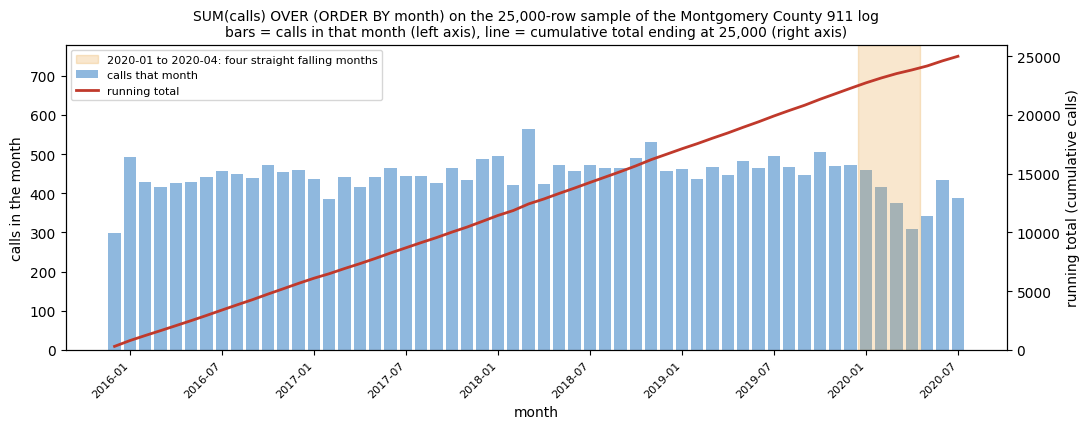

In [21]:
import matplotlib.pyplot as plt

print("monthly calls: min", int(running["calls"].min()), "max", int(running["calls"].max()))
print("mean calls/month, whole series :", round(running["calls"].mean(), 1))
band = ["2020-01", "2020-02", "2020-03", "2020-04"]
print("mean calls/month, Jan-Apr 2020 :",
      round(running.loc[running["month"].isin(band), "calls"].mean(), 1))

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.bar(running["month"], running["calls"], color="#8fb8de", label="calls that month")
ax.set_ylabel("calls in the month")
ax.set_xlabel("month")
ax.set_ylim(0, 780)          # headroom: the legend sits on empty paper instead of on the bars
ticks = [i for i, m in enumerate(running["month"]) if m.endswith(("-01", "-07"))]
ax.set_xticks(ticks)
ax.set_xticklabels(running["month"][ticks], rotation=45, ha="right", fontsize=8)

first_2020 = list(running["month"]).index("2020-01")
ax.axvspan(first_2020 - 0.5, first_2020 + 3.5, color="#e8a33d", alpha=0.25,
           label="2020-01 to 2020-04: four straight falling months")

ax2 = ax.twinx()
ax2.plot(running["month"], running["running_total"], color="#c0392b", lw=2, label="running total")
ax2.set_ylabel("running total (cumulative calls)")
ax2.set_ylim(0, 26000)

ax.set_title("SUM(calls) OVER (ORDER BY month) on the 25,000-row sample of the Montgomery County 911 log\n"
             "bars = calls in that month (left axis), line = cumulative total ending at 25,000 (right axis)",
             fontsize=10)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

Read the picture against the numbers it just printed.

The bars wobble between **298 and 563** calls a month with no trend, so the cumulative line is close
to straight. The shaded band is the January–April 2020 run, and it is worth looking at twice:
**the bars step clearly down through it, and the red line does not.** Those four months average
**390 calls against 446 for the whole series** — about 13% below the normal rate, sustained for a
third of a year — and on a line climbing to 25,000 that gap is almost invisible.

That is the honest weakness of a running total, and it is why this figure is here rather than a
prettier one. A cumulative line always rises, so it makes every series look calm and every trend
look inevitable. The information is in the **slope**, and the eye is bad at slopes. If the question
is *"did the rate change?"*, plot the rate — the bars — and keep the running total for *"how much
have we accumulated so far?"*, which is the only question it answers well.

---

## Part 5 — Your turn

Six exercises. **You write the SQL.** Each cell gives you the question and the exact columns to
return; you fill in the query, run the cell, and `check()` tells you whether the result is right.

`check()` compares a fingerprint of your result against the expected one. It never shows you the
answer. It does tell you the shape it expected, and how many of your rows are correct, so a near
miss is debuggable. Column *names* are ignored — column **order** is not, so return the columns in
the order the question lists them.

Run the next cell once to define the checker.

In [22]:
EXPECTED = {
    "E1": {"shape": (1, 2), "rows": ["c7fdf8c4d2f0"], "ordered": "c7fdf8c4d2f0"},
    "E2": {"shape": (1, 2), "rows": ["56f02c01e748"], "ordered": "56f02c01e748"},
    "E3": {"shape": (5, 3), "rows": ["05b9a8a54b4f", "3645bcc0b0d0", "3e35d57099a6",
                                     "5a69d8380721", "82b88707efc7"],
           "ordered": "cf99ed8ce451"},
    "E4": {"shape": (6, 3), "rows": ["17786b8dbc18", "21c57cea83b1", "27e6b919c0c5",
                                     "290cd38f2461", "c39998ba8593", "f933ae57179f"],
           "ordered": "0b8b85ab81ae"},
    "E5": {"shape": (1, 3), "rows": ["f7cfddce723c"], "ordered": "f7cfddce723c"},
    "E6": {"shape": (1, 2), "rows": ["c796bc0bb3b1"], "ordered": "c796bc0bb3b1"},
}

def _canon(df):
    """One string per row, so 17 and 17.0 and ' 17 ' all compare equal."""
    out = []
    for row in df.itertuples(index=False, name=None):
        vals = []
        for v in row:
            if isinstance(v, float):
                v = int(v) if float(v).is_integer() else round(v, 4)
            vals.append("NULL" if v is None or (isinstance(v, float) and pd.isna(v))
                        else str(v).strip())
        out.append("|".join(vals))
    return out

def _h(s):
    return hashlib.sha256(s.encode()).hexdigest()[:12]

def check(name, sql):
    body = "\n".join(l for l in sql.splitlines() if not l.strip().startswith("--")).strip()
    if not body:
        print(f"{name}: nothing to check yet — write your query above and run this cell again.")
        return
    try:
        got = pd.read_sql_query(sql, con)
    except Exception as e:
        print(f"{name}: SQLite rejected this query — {type(e).__name__}: {e}")
        return
    display(got)
    exp = EXPECTED[name]
    print(f"{name}: your result is {got.shape[0]} rows x {got.shape[1]} columns; "
          f"expected {exp['shape'][0]} x {exp['shape'][1]}.")
    if got.shape[1] != exp["shape"][1]:
        print("   Wrong number of columns — return exactly the columns the question lists, in order.")
        return
    mine = _canon(got)
    hits = sum(1 for r in mine if _h(r) in exp["rows"])
    if hits == len(exp["rows"]) and got.shape[0] == exp["shape"][0]:
        if _h("~".join(mine)) == exp["ordered"]:
            print("   ✅ correct.")
        else:
            print("   ✅ every row is correct, but they are in a different order — check your ORDER BY.")
    else:
        print(f"   ❌ {hits} of your {got.shape[0]} rows match the {len(exp['rows'])} expected rows.")

print("checker ready")

checker ready


### Exercise 1 — the rows an `INNER JOIN` would eat

For the **EMS** category only, return **one row with two columns**:

1. how many EMS calls **match** a row in `zip_areas` on `(zip, twp)`,
2. how many EMS calls **do not**.

Do it in a single query, with a single join. (Hint: `LEFT JOIN`, then count with
`SUM(CASE WHEN ... THEN 1 ELSE 0 END)`.)

In [23]:
sql = """
-- your query here
"""
check("E1", sql)

E1: nothing to check yet — write your query above and run this cell again.


### Exercise 2 — measure the fan-out

Join `calls` to `zip_areas` **on township alone** and restrict to `NORRISTOWN`.
Return **one row, two columns**: the township name, and the number of rows the join produced.

Before you run it: `NORRISTOWN` has 1,515 calls. Work out the answer on paper first —
`SELECT COUNT(*) FROM zip_areas WHERE twp = 'NORRISTOWN'` tells you the multiplier.

In [24]:
sql = """
-- your query here
"""
check("E2", sql)

E2: nothing to check yet — write your query above and run this cell again.


### Exercise 3 — a CTE

Which townships are the most traffic-heavy? Using a `WITH` clause, return the **5 townships with at
least 300 calls** that have the **highest share of `Traffic` calls**.

Columns, in this order: `twp`, `calls` (all calls in that township), `traffic_calls`.
Order by the *share* (`traffic_calls / calls`) descending. Exclude rows with a `NULL` township.

Note that the share is only used for ordering — do not return it as a column.

In [25]:
sql = """
-- your query here
"""
check("E3", sql)

E3: nothing to check yet — write your query above and run this cell again.


### Exercise 4 — `ROW_NUMBER`, top N per group

For **each of the three categories**, return the **2 busiest townships**.

Columns, in this order: `category`, `twp`, `calls`. Six rows.
Order by `category`, then by `calls` descending. Exclude rows with a `NULL` township.

This is the three-step pattern from Part 4: aggregate in a CTE, number in a CTE, filter outside.

In [26]:
sql = """
-- your query here
"""
check("E4", sql)

E4: nothing to check yet — write your query above and run this cell again.


### Exercise 5 — `LAG`

For `NORRISTOWN` only, compute the month-over-month change in call volume, then return the
**single month with the largest increase**.

Columns, in this order: `month`, `calls`, `change`. One row.
Remember that the first month's change is `NULL`, and `NULL` must not win.

In [27]:
sql = """
-- your query here
"""
check("E5", sql)

E5: nothing to check yet — write your query above and run this cell again.


### Exercise 6 — a running total with a threshold

Using `SUM(...) OVER (ORDER BY month)`, compute the cumulative number of **`Fire`** calls by month.
Return the **first month at which the cumulative total reaches 2,000**.

Columns, in this order: `month`, `running_total`. One row.

In [28]:
sql = """
-- your query here
"""
check("E6", sql)

E6: nothing to check yet — write your query above and run this cell again.


### Exercise 7 — no checker, and that is the point

The fintech posting asked for one more thing: *"Ability to scope a vague business question into
something answerable, and to say clearly when the data can't answer it."*

Your manager says: **"Which townships need another ambulance?"**

Write your answer in the cell below, as comments or as a printed string. Three parts:

1. **The query you would actually run** against `calls` and `zip_areas`, and what it would show.
   (`hour` and `call_date` are in the table and you have not used them yet.)
2. **The three things it cannot tell you** that the decision needs. Be specific about columns that
   are not in this database.
3. **The one sentence you would say to the manager** before anyone spends money.

There is no fingerprint for this one. Compare your answer with the person next to you — you will
disagree, and the disagreement is the exercise.

In [29]:
answer = """
1.
2.
3.
"""
print(answer)


1.
2.
3.



---

## 💬 Discuss

Argue about these in pairs. None has one right answer.

1. **The 3,029 dropped rows.** You have to publish "calls per township" tomorrow. `INNER JOIN`
   silently drops 12.1% of calls, unevenly — `UPPER MERION` loses 31%, `POTTSTOWN` loses 2%.
   `LEFT JOIN` keeps them all but leaves a `NULL` ZIP area you cannot map. A third option is to put
   the unmatched calls in a visible "UNKNOWN ZIP" bucket. Pick one and defend it. Which of the
   three is most likely to be quietly wrong a year from now, when someone else maintains the query?

2. **Who should have caught the fan-out?** The query that returned 162,490 rows ran without error.
   Nothing in SQLite objected. Should the tool have warned you? What would that warning have to
   know that the database does not? Now say what *you* will do instead, in one sentence, that costs
   you less than ten seconds per query.

3. **`ROW_NUMBER` or `RANK` for a leaderboard.** `HORSHAM` and `UPPER PROVIDENCE` both logged 650
   calls. A dashboard has room for a "top 12" list. `ROW_NUMBER` fits exactly 12 rows and puts one
   of them at 13th for no reason. `RANK` gives you 13 rows in a box built for 12. Which do you ship,
   and what do you tell the township that got 13th?

4. **The four falling months.** You found a real pattern — the only four-month decline in the
   series — and this table cannot say why. Your manager wants a cause by Thursday. What is the
   smallest, cheapest extra evidence that would let you distinguish "fewer emergencies happened"
   from "people called less often"? Is that evidence in any file in this repository?

5. **Sample versus full file.** Every count in this notebook is from 1 call in 27. The *ranking* of
   townships and the *share* of Traffic calls are roughly stable under that thinning; the totals are
   not. Name a decision that would be safe to take on this sample, and one that would not.

---

## ⚠️ Where this breaks

**Window functions need SQLite 3.25.0 or newer.** The SQLite documentation states: *"Window
function support was first added to SQLite with release version 3.25.0 (2018-09-15)."* CTEs are
older — the `WITH` clause arrived in **3.8.3 (2014-02-03)**. Python ships its own copy of the SQLite
engine inside the `sqlite3` module, so the version depends on your Python build, not on anything you
installed. Run the next cell on **your** machine.

In [30]:
major, minor, patch = sqlite3.sqlite_version_info
print("SQLite engine in this kernel :", sqlite3.sqlite_version)
print("window functions (>= 3.25.0) :", "yes" if (major, minor) >= (3, 25) else "NO — Part 4 will fail")
print("CTEs / WITH (>= 3.8.3)       :", "yes" if (major, minor, patch) >= (3, 8, 3) else "NO")

SQLite engine in this kernel : 3.52.0
window functions (>= 3.25.0) : yes
CTEs / WITH (>= 3.8.3)       : yes


**You cannot put a window function in `WHERE` or `HAVING`.** The window is computed after those
clauses have already chosen the rows, so the request is circular. This is the error every student
hits on their first `ROW_NUMBER`, so meet it here rather than in an exam. The next cell is
*supposed* to fail.

In [31]:
q("""
SELECT twp, COUNT(*) AS calls
FROM calls
WHERE ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) <= 3
GROUP BY twp
""")

DatabaseError: Execution failed on sql '
SELECT twp, COUNT(*) AS calls
FROM calls
WHERE ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) <= 3
GROUP BY twp
': misuse of window function ROW_NUMBER()

`DatabaseError: Execution failed on sql ... misuse of window function ROW_NUMBER()`. The class in
the traceback is pandas' `DatabaseError`, because `pd.read_sql_query` wraps whatever the driver
raised; run the same SQL through plain `sqlite3` and you get `sqlite3.OperationalError` with the
identical message. **Read the last sentence of a database error, not the first line** — the end of
the message is the engine talking. The fix here is always the same: compute the window in a CTE,
filter in the query outside it.

**Four more honest limits of this lesson:**

- **`zip_areas` was derived from `calls`, so it is a friendlier lookup table than a real one.**
  It can only contain ZIP areas that already appear in the log. A real dimension table is
  maintained separately and will contain areas with **zero** calls, plus areas that were renamed or
  merged. That means a real `LEFT JOIN` from the dimension side also has gaps — and joins can fail
  in the other direction too, which this notebook never shows you.
- **Every count here is from a 25,000-row sample, 1 call in 27.** "Traffic is 35% of calls" survives
  the thinning. "There were 8,678 traffic calls" is a sample artefact — the real log has roughly 27
  times that. Say which one you are quoting, every time.
- **Nothing here is about speed.** These tables are tiny and every query returns instantly. On a
  100-million-row transactional schema the same `LEFT JOIN` can run for an hour, `ORDER BY` inside
  `OVER` forces a sort, and a missing index turns a two-second query into a two-hour one. That is a
  different lesson, and the posting's phrase "against a large transactional schema" is asking for it.
- **`NULL` is stranger than this notebook shows.** You have seen `NULL` refuse to match in a join.
  It also makes `WHERE zip != 19422` skip the `NULL` rows, and it makes `COUNT(zip)` disagree with
  `COUNT(*)`. Every one of those has produced a wrong number in a real report.

**A named case of the failure mode.** In 2010 Carmen Reinhart and Kenneth Rogoff published a
number that was still steering budget debates three years later — it is the only evidence on the
growth consequences of public debt cited in the 2013 "Paul Ryan Budget": countries whose public
debt passes 90% of GDP average **−0.1%** real GDP growth. In April 2013 Thomas Herndon, Michael Ash and Robert Pollin
obtained the working spreadsheet and found, in a one-line footnote, that an averaging formula
covered **"lines 30 to 44 instead of lines 30 to 49"** — silently excluding five countries
(Australia, Austria, Belgium, Canada, Denmark) from the analysis. The headline above-90% figure was
computed from **71 country-years when 110 were available**; 25 of the 39 missing were dropped by
that slice alone. Nothing errored. The spreadsheet returned a completely plausible number.

Be exact about the damage, because the popular version of this story is not: Herndon, Ash and
Pollin attribute **−0.3 percentage points** to the spreadsheet slice, and the full correction from
−0.1% to **+2.2%** needs all three of their findings — that slice, RR's exclusion of early years
for Australia, Canada and New Zealand, and an equal-weighting of countries rather than of
country-years. The slice is one of three causes, not the whole story.

It is still the right case for this lesson, and there is a sting in it. The countries that formula
dropped were, in the authors' words, "selected alphabetically and, hence, likely randomly with
respect to economic relationships" — and that slice alone still took 25 of the 110 country-years,
just under a quarter of the evidence, with the headline moving anyway. **The 3,029 rows an `INNER JOIN` drops here are not random.** `UPPER MERION` loses 31% of
its calls and `POTTSTOWN` loses 2%. A biased silent drop does more damage than a random one, and
your query does it every single day until somebody counts the rows.

---

## Recap — what to keep

| construct | the question it answers | the trap |
|---|---|---|
| `INNER JOIN` | "rows that exist in both" | silently deletes unmatched rows — 3,029 here |
| `LEFT JOIN` | "all my rows, plus a match where there is one" | **multiplies** rows if the key is not unique on the right |
| anti-join (`LEFT JOIN ... WHERE right.col IS NULL`) | "which of my rows found no match?" | forgetting it exists |
| `WITH name AS (...)` | naming a step so a human can read the query | it is not a table, and not automatically faster |
| `ROW_NUMBER()` | "exactly N per group" | breaks ties arbitrarily |
| `RANK()` / `DENSE_RANK()` | "joint 12th" (with / without a gap) | returns more rows than N |
| `LAG()` | "compared with the row before" | the first row is `NULL` |
| `SUM() OVER (ORDER BY ...)` | a running total | it always rises; read the slope, not the height |

Two habits worth more than the syntax:

1. **Count the rows before and after every join.** Ten seconds. It catches fan-out and silent drops.
2. **Say which number you are quoting** — sample or full, matched or all — before anyone acts on it.

## References

Each of these is used above, not decorative.

- **SQLite, "Window Functions"** — <https://www.sqlite.org/windowfunctions.html>. Source of the
  version claim in *Where this breaks* ("first added ... with release version 3.25.0 (2018-09-15)")
  and of the list of built-in window functions. It documents seven more than this lesson uses,
  including `LEAD`, `NTILE`, `FIRST_VALUE` and `PERCENT_RANK`.
- **SQLite 3.8.3 release notes (2014-02-03)** — <https://sqlite.org/releaselog/3_8_3.html>.
  "Added support for common table expressions and the WITH clause." Source of the CTE version claim.
- **Montgomery County, PA emergency (911) call log** — Kaggle `mchirico/montcoalert`, the dataset
  behind both tables in this notebook. The repository ships a 25,000-row sample of it; see
  `Course 04/datasets/DATA.md`.
- **Herndon, T., Ash, M. and Pollin, R., "Does High Public Debt Consistently Stifle Economic
  Growth? A Critique of Reinhart and Rogoff", PERI Working Paper 322, 15 April 2013** —
  <https://peri.umass.edu/images/WP322.pdf>. Source of every figure in the named case in *Where this
  breaks*: the quoted footnote 5 ("RR averaged cells in lines 30 to 44 instead of lines 30 to 49"),
  the five excluded countries, the 71-of-110 country-years, the −0.3 percentage-point attribution,
  and the −0.1% / 2.2% headline. Lesson 03 in this folder opens on a different case of the same
  failure — Public Health England losing 15,841 COVID-19 test results in October 2020.